# SOVEREIGN Game
Standalone version for Google Colab. This notebook contains the complete SOVEREIGN environment, experiment configurations, and visualization tools.

## 1. Setup Environment
Install the required dependencies including Gymnasium for the environment API and Stable-Baselines3 for the PPO reinforcement learning algorithm.

In [1]:
!pip install gymnasium stable-baselines3 networkx matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 26.8 MB/s eta 0:00:00
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0


## 2. Define the Map Topology
This cell defines the underlying graph structure of the game board. It contains the 9 territories, their connections (edges), and the starting state (unit counts, resource values).

In [2]:
# --- TOPOLOGY DEFINITION ---
import numpy as np

# Controller ENUM
C_INVADER = 0
C_DEFENDER = 1
C_NEUTRAL = 2
C_CONTESTED = 3

TERRITORY_NAMES = [
    "Invader_Home",
    "Defender_Home",
    "Neutral_Home",
    "C1",
    "C2",
    "C3",
    "C4",
    "C5",
    "C6"
]

# Adjacency list for the graph (undirected)
ADJACENCY = {
    0: [3, 4],       # Invader Home connects to C1, C2
    1: [5, 8],       # Defender Home connects to C3, C6
    2: [6, 7],       # Neutral Home connects to C4, C5
    3: [0, 4, 6],    # C1 connects to I_Home, C2, C4
    4: [0, 3, 5],    # C2 connects to I_Home, C1, C3
    5: [1, 4, 8],    # C3 connects to D_Home, C2, C6
    6: [2, 3, 7],    # C4 connects to N_Home, C1, C5
    7: [2, 6, 8],    # C5 connects to N_Home, C4, C6
    8: [1, 5, 7]     # C6 connects to D_Home, C3, C5
}

# Initial controllers
INIT_CONTROLLERS = [
    C_INVADER,
    C_DEFENDER,
    C_NEUTRAL,
    C_CONTESTED,
    C_CONTESTED,
    C_CONTESTED,
    C_CONTESTED,
    C_CONTESTED,
    C_CONTESTED
]

# Territory values
RESOURCE_VALUES = [
    0.2, 0.2, 0.2,  # Homes
    0.1, 0.1, 0.1,  # C1, C2, C3
    0.1, 0.1, 0.1   # C4, C5, C6
]

STRATEGIC_VALUES = [
    1.0, 1.0, 1.0,  # Homes
    0.5, 0.5, 0.5,  # C1, C2, C3
    0.5, 0.5, 0.5   # C4, C5, C6
]

# Initial Units
INIT_UNITS_INVADER = [12, 0, 0, 0, 0, 0, 0, 0, 0]
INIT_UNITS_DEFENDER = [0, 6, 0, 0, 0, 0, 0, 0, 0]
INIT_UNITS_NEUTRAL = [0, 0, 4, 0, 0, 0, 0, 0, 0]

INIT_STRIKE_INVADER = 3
INIT_STRIKE_DEFENDER = 1
INIT_STRIKE_NEUTRAL = 0

def get_adjacent_territories(t_id):
    return ADJACENCY.get(t_id, [])

def is_adjacent(t1, t2):
    return t2 in get_adjacent_territories(t1)


## 3. The SOVEREIGN Environment
This cell contains the core `SovereignEnv` class. It implements the Gymnasium interface (`reset`, `step`) and houses the complex logic for the Drift-Diffusion neutral posture, the dense reward function, and the asymmetric combat rules.

In [3]:
# --- ENVIRONMENT DEFINITION ---
import gymnasium as gym
from gymnasium import spaces
import numpy as np

from __main__ import (
    C_INVADER, C_DEFENDER, C_NEUTRAL, C_CONTESTED,
    INIT_CONTROLLERS, RESOURCE_VALUES, STRATEGIC_VALUES,
    INIT_UNITS_INVADER, INIT_UNITS_DEFENDER, INIT_UNITS_NEUTRAL,
    INIT_STRIKE_INVADER, INIT_STRIKE_DEFENDER, INIT_STRIKE_NEUTRAL,
    get_adjacent_territories, is_adjacent
)

class SovereignEnv(gym.Env):
    """
    SOVEREIGN Game Environment
    A deterministic-core, stochastic-politics strategic simulation.
    """

    def __init__(self, config=None):
        super().__init__()
        if config is None:
            config = {}

        self.T_max = config.get("T_max", 100)
        self.sanction_threshold = config.get("sanction_threshold", 0.60)

        # Ablations
        self.use_legitimacy = config.get("use_legitimacy", True)
        self.use_occ_cost = config.get("use_occ_cost", True)
        self.use_neutral = config.get("use_neutral", True)

        # Weights
        self.w_T = config.get("w_T", 0.30)
        self.w_R = config.get("w_R", 0.20)
        self.w_O = config.get("w_O", 0.25)
        self.w_L = config.get("w_L", 0.15)
        self.w_S = config.get("w_S", 0.20)
        self.w_I = config.get("w_I", 0.10)

        # Action Space: MultiDiscrete [Political (5), Military (4)]
        self.action_space = spaces.MultiDiscrete([5, 4])

        # Observation Space
        # M: 9 territories, 4 controller states (I, D, N, Contested)
        # U_I, U_D: 9 territories, up to 100 units
        self.observation_space = spaces.Dict({
            "M": spaces.Box(low=0, high=1, shape=(9, 4), dtype=np.int32),
            "U_I": spaces.Box(low=0, high=100, shape=(9,), dtype=np.int32),
            "U_D": spaces.Box(low=0, high=100, shape=(9,), dtype=np.int32),
            "S_I": spaces.Box(low=0, high=10, shape=(1,), dtype=np.int32),
            "S_D": spaces.Box(low=0, high=10, shape=(1,), dtype=np.int32),
            "L": spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32),
            "E": spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32),
            "theta": spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32),
            "t_occ": spaces.Box(low=0, high=self.T_max, shape=(1,), dtype=np.int32),
        })

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.controllers = list(INIT_CONTROLLERS)
        self.u_i = list(INIT_UNITS_INVADER)
        self.u_d = list(INIT_UNITS_DEFENDER)
        self.u_n = list(INIT_UNITS_NEUTRAL)
        self.s_i = INIT_STRIKE_INVADER
        self.s_d = INIT_STRIKE_DEFENDER
        self.s_n = INIT_STRIKE_NEUTRAL

        self.L = 1.0
        self.E = 1.0
        self.D_E = 1.0  # Defender E
        self.theta = 0.0
        self.t_occ = 0
        self.t = 0

        # Tracking thresholds to allow hysteresis
        self.sanctions_active = False
        self.sanctions_cooldown = 0
        self.neutral_joined_defender = False
        self.neutral_supply_routes_open = False
        self.neutral_allied_invader = False

        return self._get_obs(), {}

    def _get_obs(self):
        M = np.zeros((9, 4), dtype=np.int32)
        for i, c in enumerate(self.controllers):
            M[i, c] = 1

        return {
            "M": M,
            "U_I": np.array(self.u_i, dtype=np.int32),
            "U_D": np.array(self.u_d, dtype=np.int32),
            "S_I": np.array([self.s_i], dtype=np.int32),
            "S_D": np.array([self.s_d], dtype=np.int32),
            "L": np.array([self.L], dtype=np.float32),
            "E": np.array([self.E], dtype=np.float32),
            "theta": np.array([self.theta], dtype=np.float32),
            "t_occ": np.array([self.t_occ], dtype=np.int32)
        }

    def _get_frontline(self, attacker_c, target_c):
        """Find adjacent pairs of territories controlled by attacker and target."""
        pairs = []
        for i in range(9):
            if self.controllers[i] == attacker_c:
                for j in get_adjacent_territories(i):
                    if self.controllers[j] == target_c:
                        pairs.append((i, j))
        return pairs

    def _combat_roll(self, u_atk, u_def, def_home=False):
        """Perform a combat roll. Return True if attacker wins."""
        if u_atk <= 0: return False
        if u_def <= 0: return True
        eff_def = u_def * 1.2 if def_home else u_def
        p_win = u_atk / (u_atk + eff_def)
        return self.np_random.random() < p_win

    def step(self, action):
        a_pol, a_mil = action

        prev_controlled_resources = sum([RESOURCE_VALUES[i] for i in range(9) if self.controllers[i] == C_INVADER])

        # 1 & 2. Invader Actions
        self._apply_political_action(a_pol)
        mil_event = self._apply_military_action(a_mil)

        # 3. Defender Responds
        self._defender_policy(mil_event)

        # 4. Resolve military outcomes -> Handled within apply functions for simplicity

        # 5. Update territory control map M
        # Automatically claim contested territories if Invader units move in
        for i in range(9):
            if self.u_i[i] > 0 and self.controllers[i] == C_CONTESTED:
                self.controllers[i] = C_INVADER
            if self.u_d[i] > 0 and self.controllers[i] == C_CONTESTED:
                self.controllers[i] = C_DEFENDER

        # 6. Update L, E, t_occ
        has_non_home = any(self.controllers[i] == C_INVADER and i != 0 for i in range(9))
        if has_non_home:
            self.t_occ += 1
        else:
            self.t_occ = 0

        if self.use_legitimacy:
            self.L = np.clip(self.L, 0.0, 1.0)
        else:
            self.L = 1.0 # Ablated

        # 7. Sample Neutral Posture Shift
        if self.use_neutral:
            mu = 0.04 * (1 - self.L) \
                 + 0.05 * (a_mil == 0) \
                 + 0.10 * (a_mil == 3) \
                 - 0.04 * (a_pol == 3) \
                 - 0.03 * (a_pol == 0) \
                 + 0.03 * (self.t_occ / self.T_max)

            noise = self.np_random.normal(0, 0.02)
            self.theta = np.clip(self.theta + mu + noise, -1.0, 1.0)
        else:
            self.theta = 0.0

        # 8. Check Threshold Events
        self._check_thresholds()

        # 9. Compute Reward
        r_t, done, info = self._compute_reward_and_terminal(a_pol, prev_controlled_resources)

        self.t += 1
        if self.t >= self.T_max:
            done = True

        return self._get_obs(), r_t, done, False, info

    def _apply_political_action(self, a_pol):
        if a_pol == 0: # SEEK_ALLIANCE
            self.L += 0.01
            self.theta -= 0.05
        elif a_pol == 1: # IMPOSE_SANCTION
            self.L -= 0.02
            self.theta += 0.04
            self.D_E -= 0.03
        elif a_pol == 2: # ISSUE_THREAT
            self.L -= 0.03
            self.theta += 0.03
        elif a_pol == 3: # NEGOTIATE
            self.L += 0.03
            self.theta -= 0.04
        elif a_pol == 4: # DO_NOTHING
            if self.L < 0.5:
                self.L -= 0.01

    def _apply_military_action(self, a_mil):
        # 0: ADVANCE, 1: HOLD, 2: WITHDRAW, 3: STRIKE
        event = "HOLD"

        if a_mil == 0: # ADVANCE
            self.L -= 0.05
            # Find best adjacent target to advance into
            targets = []
            for i in range(9):
                if self.controllers[i] == C_INVADER:
                    for j in get_adjacent_territories(i):
                        if self.controllers[j] != C_INVADER and j != 2: # Not neutral home
                            targets.append((i, j, STRATEGIC_VALUES[j]))

            if targets:
                # Pick highest strategic value target
                targets.sort(key=lambda x: x[2], reverse=True)
                src, target, _ = targets[0]

                # Commit 1 unit to advance
                if self.u_i[src] > 0:
                    event = "ADVANCE"
                    if self.u_d[target] > 0:
                        # Combat
                        win = self._combat_roll(self.u_i[src], self.u_d[target], def_home=(target==1))
                        if win:
                            self.u_d[target] -= 1
                        else:
                            self.u_i[src] -= 1
                    else:
                        # Move unit
                        self.u_i[src] -= 1
                        self.u_i[target] += 1
                        self.controllers[target] = C_INVADER

        elif a_mil == 2: # WITHDRAW
            self.L += 0.02
            # Find a non-home territory to abandon
            for i in range(9):
                if self.controllers[i] == C_INVADER and i != 0:
                    # Move units back to home or adjacent invader territory
                    adj_inv = [j for j in get_adjacent_territories(i) if self.controllers[j] == C_INVADER]
                    dest = adj_inv[0] if adj_inv else 0
                    self.u_i[dest] += self.u_i[i]
                    self.u_i[i] = 0
                    self.controllers[i] = C_CONTESTED
                    event = "WITHDRAW"
                    break

        elif a_mil == 3: # STRIKE
            if self.s_i > 0:
                self.L -= 0.08
                # Find frontline
                fronts = self._get_frontline(C_INVADER, C_DEFENDER)
                if fronts:
                    src, target = fronts[0] # Just pick first
                    win = self._combat_roll(self.u_i[src], self.u_d[target], def_home=(target==1))
                    event = "STRIKE"
                    self.s_i -= 1 # Consume one strike unit
                    if win:
                        self.u_d[target] -= 1
                        if self.u_d[target] == 0 and self.controllers[target] == C_DEFENDER and target != 1:
                            self.controllers[target] = C_CONTESTED
                    else:
                        self.u_i[src] -= 1

        return event

    def _defender_policy(self, invader_event):
        # Rational baseline: counter-attack if struck or advanced upon
        if invader_event in ["STRIKE", "ADVANCE"]:
            fronts = self._get_frontline(C_DEFENDER, C_INVADER)
            if fronts:
                src, target = fronts[0]
                win = self._combat_roll(self.u_d[src], self.u_i[target], def_home=(target==0))
                if win:
                    self.u_i[target] -= 1
                    if self.u_i[target] == 0 and self.controllers[target] == C_INVADER and target != 0:
                        self.controllers[target] = C_CONTESTED
                else:
                    self.u_d[src] -= 1

    def _check_thresholds(self):
        # Sanctions
        if self.theta > self.sanction_threshold:
            self.sanctions_active = True
            self.sanctions_cooldown = 5
        elif self.sanctions_active and self.theta < 0.50:
            self.sanctions_cooldown -= 1
            if self.sanctions_cooldown <= 0:
                self.sanctions_active = False

        if self.sanctions_active:
            self.E = max(0.0, self.E - 0.01)

        # Coalition / War Support
        if self.theta > 0.85 and not self.neutral_joined_defender:
            self.neutral_joined_defender = True
            self.u_d[1] += 2 # Give defender 2 units at home
            self.L -= 0.10

        if self.theta < -0.85 and not self.neutral_allied_invader:
            self.neutral_allied_invader = True
            self.D_E = max(0.0, self.D_E - 0.01) # Example penalty
            self.L -= 0.05

        self.neutral_supply_routes_open = (self.theta < -0.60)

    def _compute_reward_and_terminal(self, a_pol, prev_controlled_resources):
        r = 0.0
        done = False
        info = {}

        # Positive
        current_res = sum([RESOURCE_VALUES[i] for i in range(9) if self.controllers[i] == C_INVADER])
        r += self.w_T * current_res

        delta_res = current_res - prev_controlled_resources
        if delta_res > 0:
            r += self.w_R * delta_res

        # Negative
        occ_cost_multiplier = 0.7 if self.neutral_supply_routes_open else 1.0
        if self.use_occ_cost:
            r -= self.w_O * (self.t_occ / self.T_max) * occ_cost_multiplier

        if self.use_legitimacy:
            r -= self.w_L * (1 - self.L)

        if self.sanctions_active:
            r -= self.w_S * (1 - self.E)

        # Insurgency
        if self.t_occ > 0:
            p_insurgency = 1 - np.exp(-0.05 * self.t_occ)
            if self.np_random.random() < p_insurgency:
                r -= self.w_I
                # Destroy one unit
                invader_held = [i for i in range(9) if self.u_i[i] > 0]
                if invader_held:
                    self.u_i[self.np_random.choice(invader_held)] -= 1

        # Terminal Conditions
        total_inv_units = sum(self.u_i)
        if self.L <= 0:
            done = True
            r -= 50
            info["terminal_reason"] = "political_collapse"
        elif total_inv_units <= 0:
            done = True
            r -= 30
            info["terminal_reason"] = "military_defeat"
        elif a_pol == 3 and self.L > 0.6 and self.theta < 0:
            # Negotiated settlement
            if self.np_random.random() < 0.5:
                done = True
                r += 40
                info["terminal_reason"] = "diplomatic_resolution"
        elif sum([1 for i in range(9) if self.controllers[i] == C_INVADER]) == 8:
            # All non-neutral controlled
            done = True
            r += 10
            info["terminal_reason"] = "total_conquest"

        return r, done, info


## 4. Register the Environment
Here we register our custom `SovereignEnv` with Gymnasium so that it can be created using `gym.make('Sovereign-v0')`.

In [4]:

import gymnasium as gym
from gymnasium.envs.registration import register

# Register the environment
try:
    register(
        id='Sovereign-v0',
        entry_point='__main__:SovereignEnv',
        max_episode_steps=100,
    )
    print("Environment registered successfully!")
except Exception as e:
    print("Environment already registered or error:", e)


Environment registered successfully!


## 5. Define and Run Experiments
This cell defines the Core Experimental Protocol, including the required ablation studies and the parameter impact analysis. It uses Proximal Policy Optimization (PPO) to train an agent for each scenario and saves the evaluation results.

In [5]:
# --- TRAINING AND EVALUATION ---
import json
import numpy as np
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

EXPERIMENTS = [
    {
        "name": "Full model",
        "config": {"use_legitimacy": True, "use_occ_cost": True, "use_neutral": True}
    },
    {
        "name": "No legitimacy",
        "config": {"use_legitimacy": False, "use_occ_cost": True, "use_neutral": True}
    },
    {
        "name": "No occupation cost",
        "config": {"use_legitimacy": True, "use_occ_cost": False, "use_neutral": True}
    },
    {
        "name": "No neutral posture",
        "config": {"use_legitimacy": True, "use_occ_cost": True, "use_neutral": False}
    },
    {
        "name": "Baseline (all off)",
        "config": {"use_legitimacy": False, "use_occ_cost": False, "use_neutral": False}
    },
    {
        "name": "Early Sanctions",
        "config": {"use_legitimacy": True, "use_occ_cost": True, "use_neutral": True, "sanction_threshold": 0.30}
    }
]

def train_and_evaluate():
    results = {}

    # 50k steps is usually enough for a simple discrete Gym environment,
    # but we will use 100k to ensure the policy converges nicely.
    TOTAL_TIMESTEPS = 100000
    EVAL_EPISODES = 50

    for exp in EXPERIMENTS:
        name = exp["name"]
        print(f"\\n--- Training Experiment: {name} ---")

        # Create env with config
        env = gym.make("Sovereign-v0", config=exp["config"])

        # Using MultiInputPolicy since observation_space is a Dict
        model = PPO("MultiInputPolicy", env, verbose=0, n_steps=2048, ent_coef=0.01)
        model.learn(total_timesteps=TOTAL_TIMESTEPS)

        # Evaluate
        print(f"Evaluating {name}...")
        mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=EVAL_EPISODES)

        # Manually play a few episodes to gather action statistics
        actions_taken = {"political": [], "military": []}
        terminal_reasons = []

        for _ in range(EVAL_EPISODES):
            obs, info = env.reset()
            done = False
            while not done:
                action, _states = model.predict(obs, deterministic=True)
                actions_taken["political"].append(int(action[0]))
                actions_taken["military"].append(int(action[1]))
                obs, reward, done, truncated, info = env.step(action)
                if done or truncated:
                    terminal_reasons.append(info.get("terminal_reason", "max_steps"))

        # Calculate action frequencies
        total_steps = len(actions_taken["political"])
        freq_negotiate = sum(1 for a in actions_taken["political"] if a == 3) / total_steps
        freq_advance = sum(1 for a in actions_taken["military"] if a == 0) / total_steps
        freq_strike = sum(1 for a in actions_taken["military"] if a == 3) / total_steps

        # Terminal reason frequencies
        unique_reasons = set(terminal_reasons)
        reason_freqs = {r: terminal_reasons.count(r) / EVAL_EPISODES for r in unique_reasons}

        print(f"Mean Reward: {mean_reward:.2f} +/- {std_reward:.2f}")
        print(f"Freq NEGOTIATE: {freq_negotiate:.1%}")
        print(f"Freq ADVANCE:   {freq_advance:.1%}")
        print(f"Freq STRIKE:    {freq_strike:.1%}")
        print(f"Terminal Reasons: {reason_freqs}")

        results[name] = {
            "mean_reward": float(mean_reward),
            "std_reward": float(std_reward),
            "freq_negotiate": float(freq_negotiate),
            "freq_advance": float(freq_advance),
            "freq_strike": float(freq_strike),
            "terminal_reasons": reason_freqs
        }

        # Save model if desired
        # model.save(f"sovereign_{name.replace(' ', '_').lower()}")

    # Save results to JSON
    with open("experiment_results.json", "w") as f:
        json.dump(results, f, indent=4)

    print("\\nAll experiments completed and results saved to experiment_results.json")

if __name__ == "__main__":
    train_and_evaluate()


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


\n--- Training Experiment: Full model ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Evaluating Full model...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Mean Reward: 40.26 +/- 0.21
Freq NEGOTIATE: 100.0%
Freq ADVANCE:   99.1%
Freq STRIKE:    0.0%
Terminal Reasons: {'diplomatic_resolution': 1.0}
\n--- Training Experiment: No legitimacy ---
Evaluating No legitimacy...
Mean Reward: 40.26 +/- 0.23
Freq NEGOTIATE: 100.0%
Freq ADVANCE:   85.3%
Freq STRIKE:    0.0%
Terminal Reasons: {'diplomatic_resolution': 1.0}
\n--- Training Experiment: No occupation cost ---
Evaluating No occupation cost...
Mean Reward: 40.21 +/- 0.20
Freq NEGOTIATE: 100.0%
Freq ADVANCE:   82.0%
Freq STRIKE:    0.0%
Terminal Reasons: {'diplomatic_resolution': 1.0}
\n--- Training Experiment: No neutral posture ---
Evaluating No neutral posture...
Mean Reward: 6.00 +/- 0.00
Freq NEGOTIATE: 100.0%
Freq ADVANCE:   0.0%
Freq STRIKE:    0.0%
Terminal Reasons: {'max_steps': 1.0}
\n--- Training Experiment: Baseline (all off) ---
Evaluating Baseline (all off)...
Mean Reward: 6.00 +/- 0.00
Freq NEGOTIATE: 0.0%
Freq ADVANCE:   0.0%
Freq STRIKE:    0.0%
Terminal Reasons: {'max_steps'

## 6. Visualize Results
Finally, this cell generates and displays the network graph of the game board and a bar chart showing the emergence of the peace-dominant policy across the different experiments.

Saved sovereign_map.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Saved experiment_results.png
Map Topology:


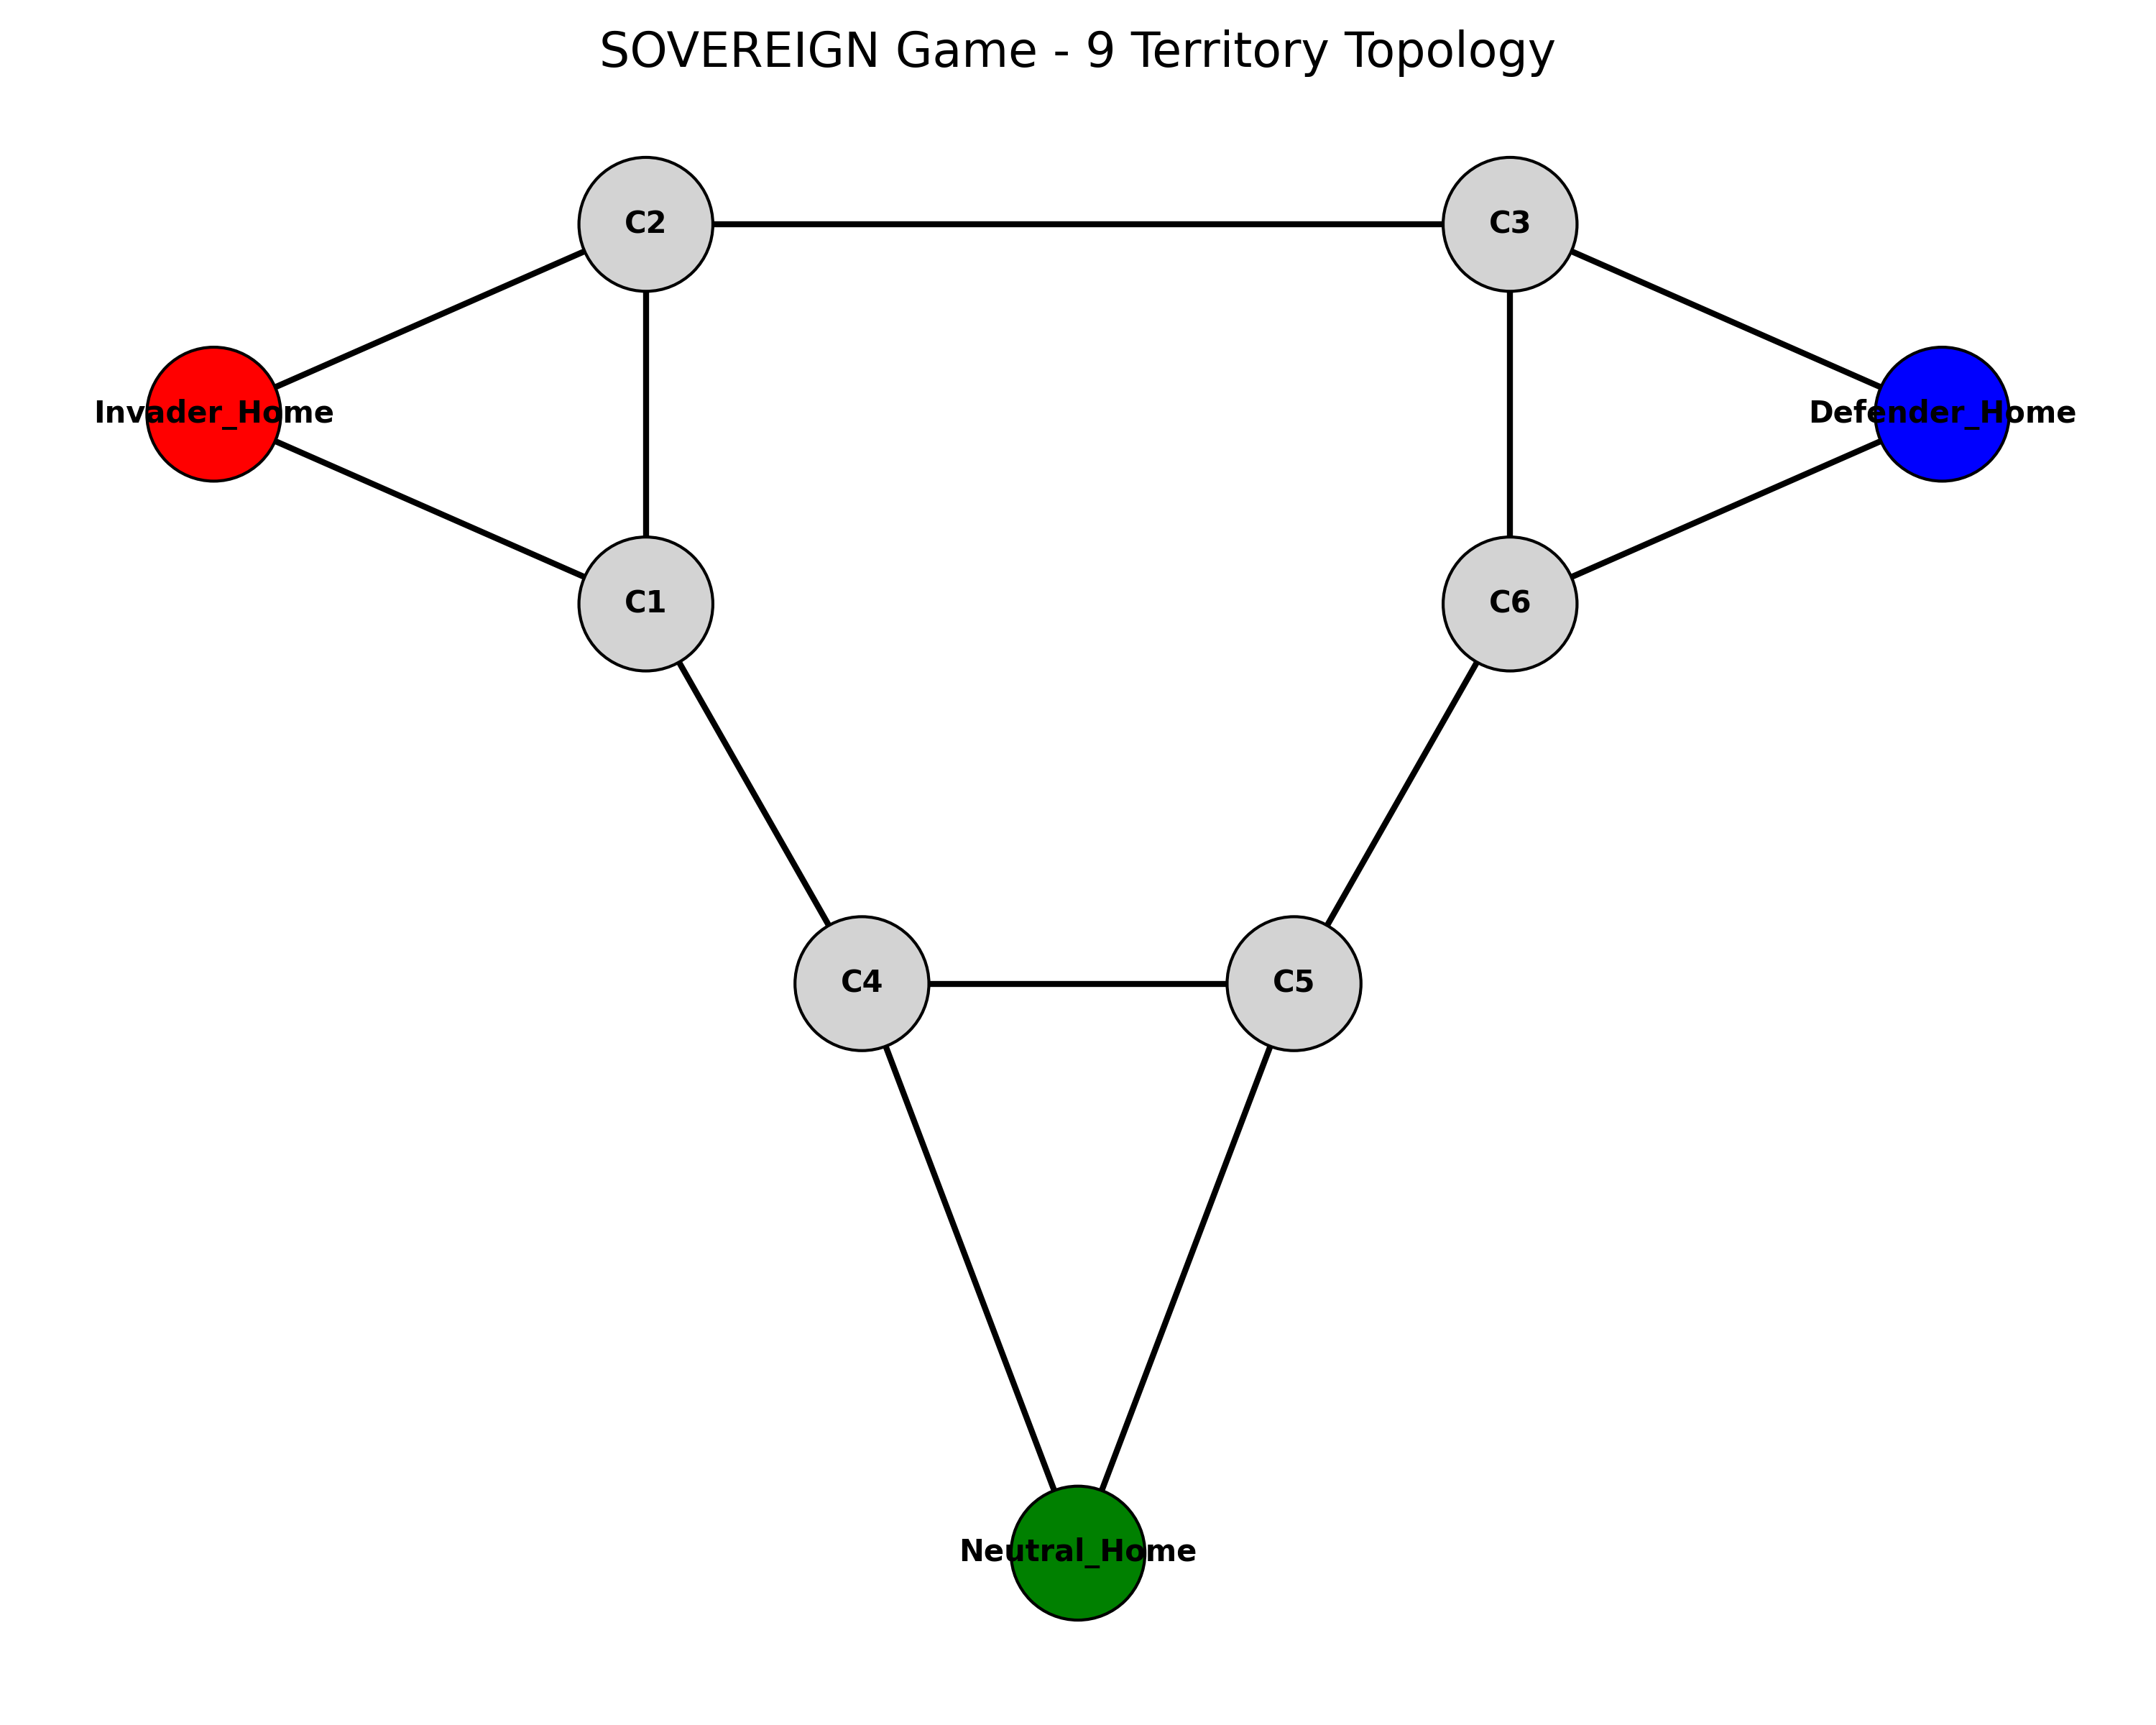


Experiment Results:


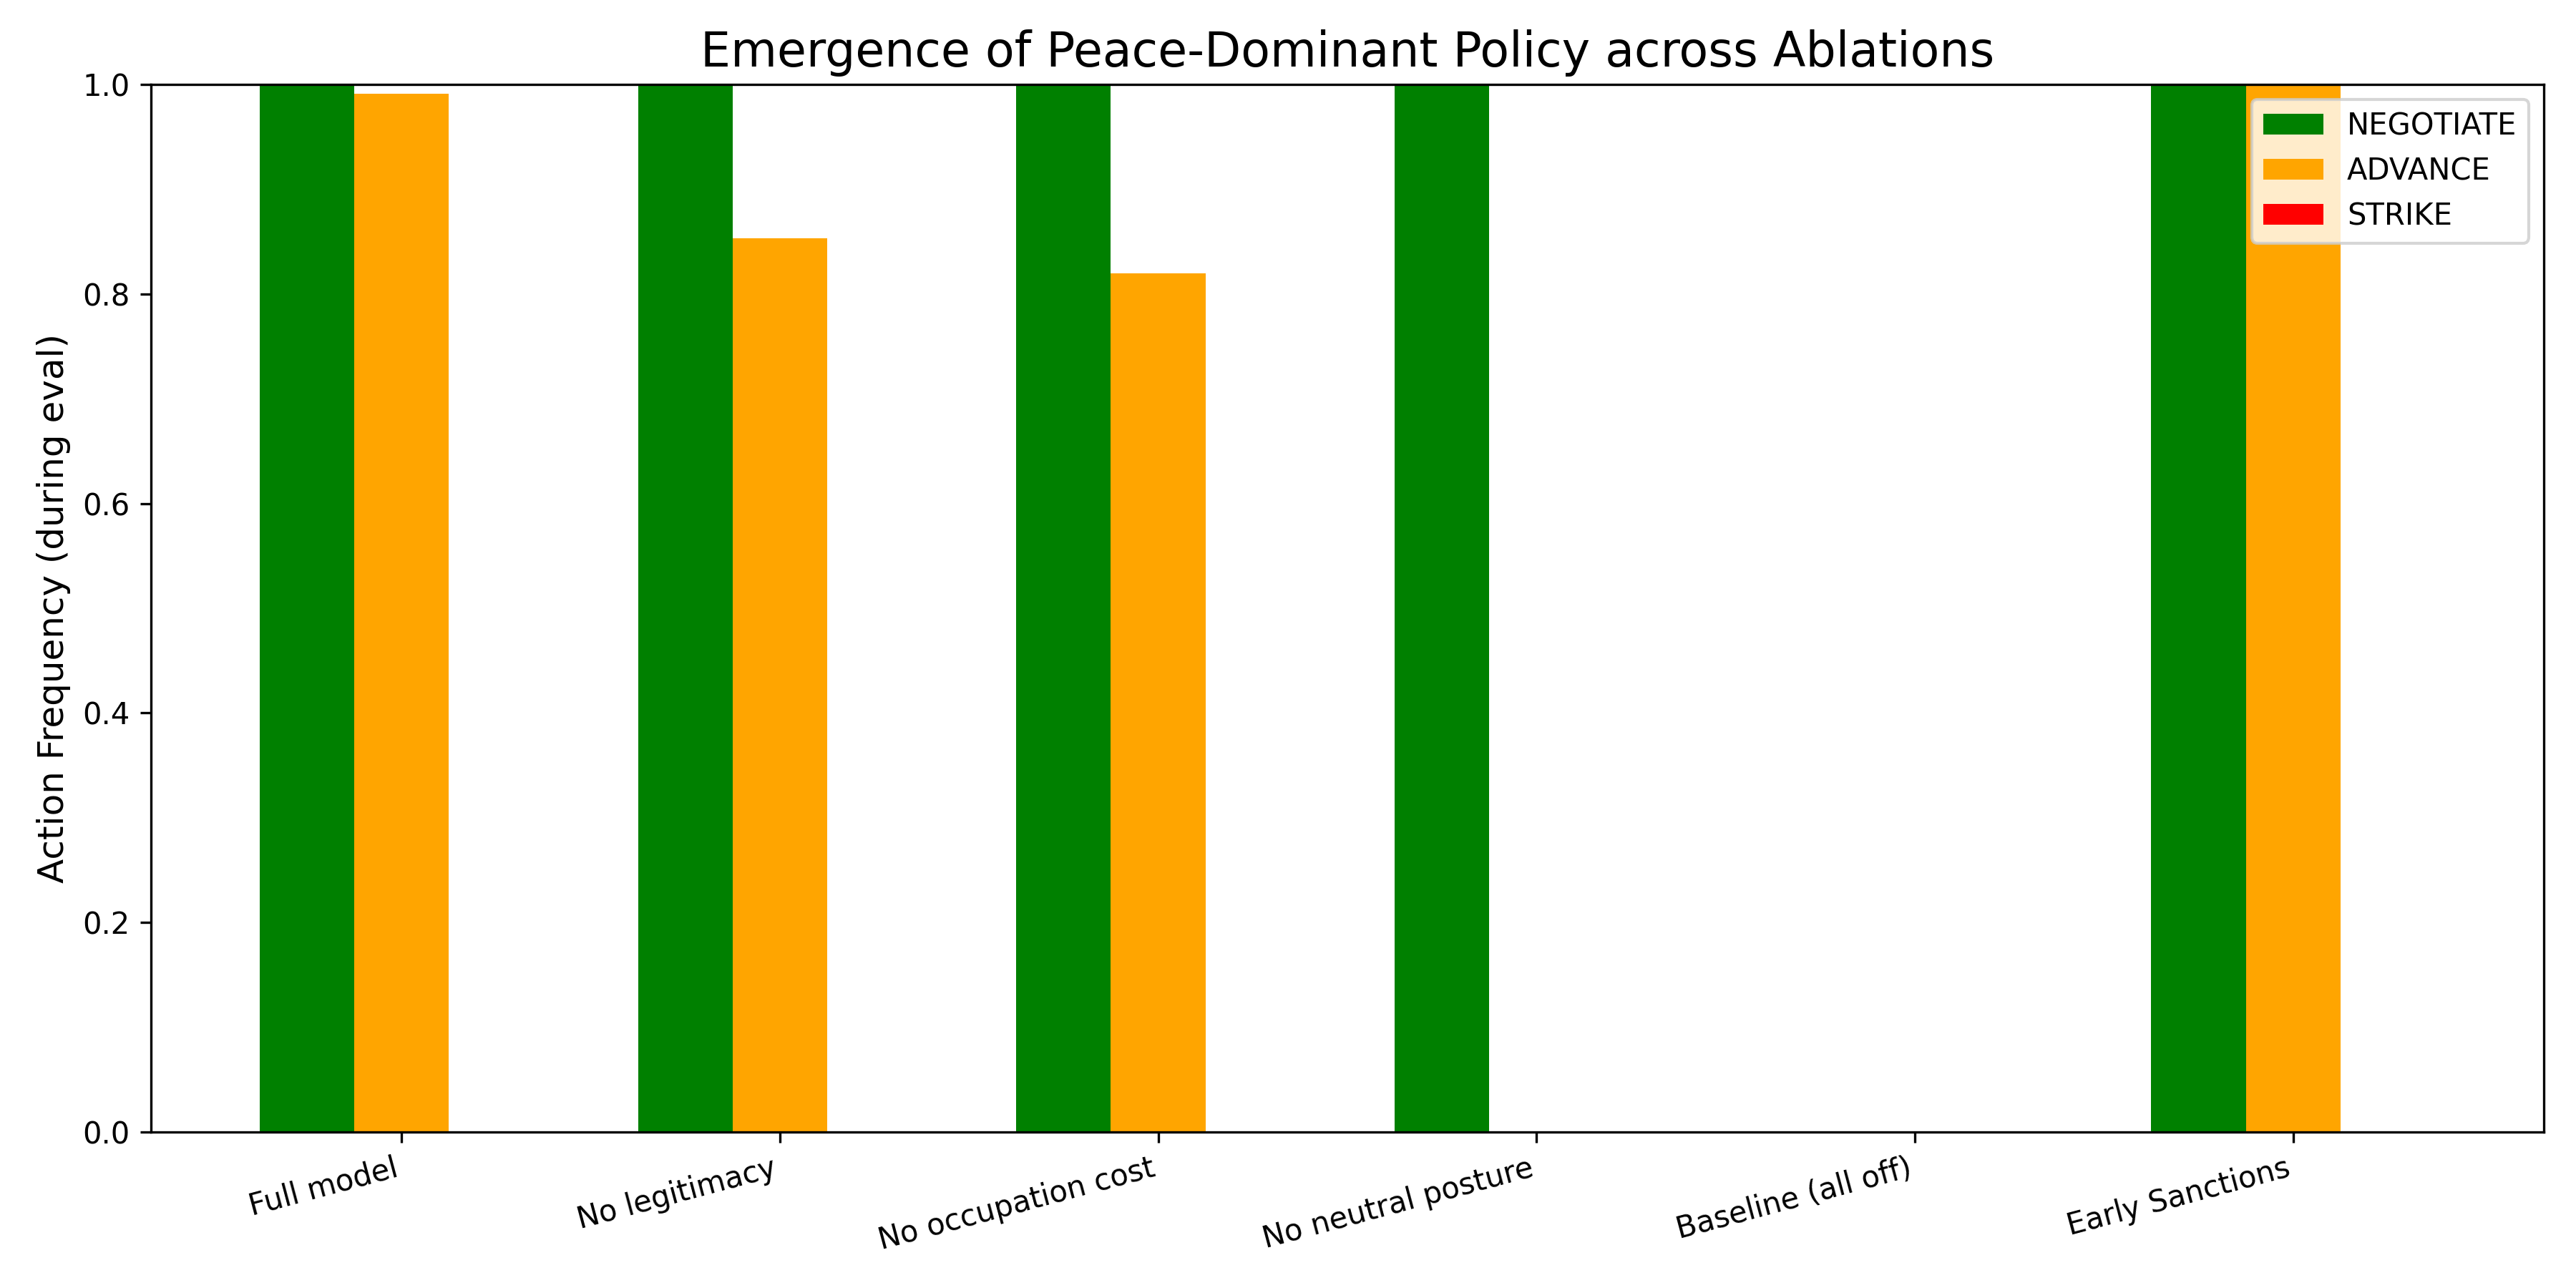

In [6]:
# --- VISUALIZATION ---
import json
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os


def draw_map():
    G = nx.Graph(ADJACENCY)

    # Define a nice layout
    pos = {
        0: (-2, 1),   # Invader Home
        1: (2, 1),    # Defender Home
        2: (0, -2),   # Neutral Home
        3: (-1, 0.5), # C1
        4: (-1, 1.5), # C2
        5: (1, 1.5),  # C3
        6: (-0.5, -0.5), # C4
        7: (0.5, -0.5),  # C5
        8: (1, 0.5)   # C6
    }

    colors = []
    for i in range(9):
        if i == 0:
            colors.append('red') # Invader
        elif i == 1:
            colors.append('blue') # Defender
        elif i == 2:
            colors.append('green') # Neutral
        else:
            colors.append('lightgray') # Contested

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=2000, edgecolors='black')
    nx.draw_networkx_edges(G, pos, width=2)

    labels = {i: TERRITORY_NAMES[i] for i in range(9)}
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight='bold')

    plt.title("SOVEREIGN Game - 9 Territory Topology", fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('sovereign_map.png', dpi=300)
    plt.close()
    print("Saved sovereign_map.png")

def plot_experiments():
    if not os.path.exists("experiment_results.json"):
        print("experiment_results.json not found! Please run train.py first.")
        return

    with open("experiment_results.json", "r") as f:
        results = json.load(f)

    names = list(results.keys())

    # We want to plot the frequency of NEGOTIATE vs ADVANCE vs STRIKE
    freq_negotiate = [results[n]["freq_negotiate"] for n in names]
    freq_advance = [results[n]["freq_advance"] for n in names]
    freq_strike = [results[n]["freq_strike"] for n in names]

    x = np.arange(len(names))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 6))

    rects1 = ax.bar(x - width, freq_negotiate, width, label='NEGOTIATE', color='green')
    rects2 = ax.bar(x, freq_advance, width, label='ADVANCE', color='orange')
    rects3 = ax.bar(x + width, freq_strike, width, label='STRIKE', color='red')

    ax.set_ylabel('Action Frequency (during eval)', fontsize=12)
    ax.set_title('Emergence of Peace-Dominant Policy across Ablations', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right')
    ax.legend()

    ax.set_ylim([0, 1.0])

    plt.tight_layout()
    plt.savefig('experiment_results.png', dpi=300)
    plt.close()
    print("Saved experiment_results.png")

if __name__ == "__main__":
    draw_map()
    plot_experiments()


# Display the results inline
from IPython.display import Image, display

print('Map Topology:')
display(Image('sovereign_map.png'))

print('\nExperiment Results:')
display(Image('experiment_results.png'))